In [8]:
import pandas as pd
from src.helper_functions import Globals
import matplotlib
import asyncio
from codetiming import Timer
from src.helper_functions import AsyncAPIFunctions, ExcelOperations, TradesOverview
from src.technical_analysis import TradeTechnicalRequests
from src.main_run import main
import matplotlib.pyplot as plt

In [10]:
# async def main():
#     ...
try:
    loop = asyncio.get_running_loop()
except RuntimeError:  # 'RuntimeError: There is no current event loop...'
    loop = None
if loop and loop.is_running():
    print('Async event loop already running. Adding coroutine to the event loop.')
    tsk = loop.create_task(main())
    # ^-- https://docs.python.org/3/library/asyncio-task.html#task-object
    # Optionally, a callback function can be executed when the coroutine completes
    tsk.add_done_callback(
        lambda t: print(f'Task done with result={t.result()}  << return val of main()'))
else:
    print('Starting new event loop')
    asyncio.run(main())

Async event loop already running. Adding coroutine to the event loop.
start process
now get trades
Task done with result=[None, None, None, None]  << return val of main()


In [11]:
pd.set_option("display.max.columns", None)

In [12]:
len(Globals.DATAFRAME_LIST)

12

In [13]:
df = Globals.DATAFRAME_LIST[11]

In [14]:
df.head()

,symbol,date,calendarYear,period,revenuePerShare,netIncomePerShare,operatingCashFlowPerShare,freeCashFlowPerShare,cashPerShare,bookValuePerShare,tangibleBookValuePerShare,shareholdersEquityPerShare,interestDebtPerShare,marketCap,enterpriseValue,peRatio,priceToSalesRatio,pocfratio,pfcfRatio,pbRatio,ptbRatio,evToSales,enterpriseValueOverEBITDA,evToOperatingCashFlow,evToFreeCashFlow,earningsYield,freeCashFlowYield,debtToEquity,debtToAssets,netDebtToEBITDA,currentRatio,interestCoverage,incomeQuality,dividendYield,payoutRatio,salesGeneralAndAdministrativeToRevenue,researchAndDdevelopementToRevenue,intangiblesToTotalAssets,capexToOperatingCashFlow,capexToRevenue,capexToDepreciation,stockBasedCompensationToRevenue,grahamNumber,roic,returnOnTangibleAssets,grahamNetNet,workingCapital,tangibleAssetValue,netCurrentAssetValue,investedCapital,averageReceivables,averagePayables,averageInventory,daysSalesOutstanding,daysPayablesOutstanding,daysOfInventoryOnHand,receivablesTurnover,payablesTurnover,inventoryTurnover,roe,capexPerShare
0,AURE.PA,2023-06-30,2023,Q2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28021000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.691384,0.249080,0.0,1.423659,0.0,0.0,NaN,0.0,0,0,0.050263,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,37357000.0,67374000.0,-13504000.0,0.691384,NaN,NaN,None,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0
1,AURE.PA,2022-12-31,2022,Q4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16401000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.827343,0.313160,0.0,1.818087,0.0,0.0,NaN,0.0,0,0,0.055997,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,50966000.0,58909000.0,-252000.0,0.827343,NaN,NaN,None,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0
2,AURE.PA,2022-06-30,2022,Q2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14039000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.707001,0.259470,0.0,1.604288,0.0,0.0,NaN,0.0,0,0,0.053196,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,47662000.0,60958000.0,3901000.0,0.707001,NaN,NaN,None,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0
3,AURE.PA,2021-12-31,2021,Q4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14719000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.813785,0.305572,0.0,1.864278,0.0,0.0,NaN,0.0,0,0,0.058708,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,51651000.0,55982000.0,1289000.0,0.813785,NaN,NaN,None,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0
4,AURE.PA,2021-06-30,2021,Q2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9335000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.917036,0.309904,0.0,1.801506,0.0,0.0,NaN,0.0,0,0,0.055644,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,53967000.0,51897000.0,-336000.0,0.917036,NaN,NaN,None,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0


In [15]:
%matplotlib

Using matplotlib backend: <object object at 0x00000295D70F2300>


In [16]:
%matplotlib inline

<Axes: title={'center': 'debtToEquity'}, xlabel='symbol'>

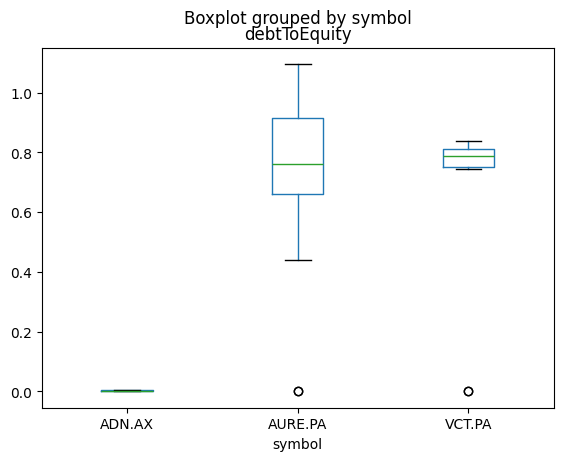

In [22]:
df.boxplot(by ='symbol', column =['debtToEquity'], grid = False) 

In [24]:
# list of key metrics
key_metric = ["peRatio", "debtToEquity", "roic", "roe", "grahamNumber", "dividendYield", "payoutRatio"]
# get the latest key metric for each symbol
latest_key_metric = df.groupby('symbol').first().sort_values('date')[key_metric]
print(latest_key_metric)

           peRatio  debtToEquity      roic       roe  grahamNumber  \
symbol                                                               
ADN.AX  -10.571427      0.004484 -0.000017 -0.000016      1.022491   
AURE.PA   0.000000      0.691384 -0.000220 -0.004642      0.000000   
VCT.PA    0.000000      0.810186  0.011297  0.017792      0.000000   

         dividendYield  payoutRatio  
symbol                               
ADN.AX        0.000000          0.0  
AURE.PA       0.008246          0.0  
VCT.PA        0.009241          0.0  


In [27]:
for count, trade in enumerate(key_metric):

    # get the list for the spefic key metric
    overview_of_key_metric = df.groupby(['symbol', 'date', f'{key_metric[count]}']).size().reset_index().sort_values(['symbol', 'date'], ascending=[True, False])

    print(overview_of_key_metric)

     symbol        date    peRatio  0
9    ADN.AX  2023-06-30 -10.571427  2
8    ADN.AX  2023-03-31 -13.142855  2
7    ADN.AX  2022-12-31 -16.923072  2
6    ADN.AX  2022-09-30 -16.923072  2
5    ADN.AX  2022-06-30 -20.685575  2
4    ADN.AX  2022-03-31 -54.669020  2
3    ADN.AX  2021-12-31 -57.812500  2
2    ADN.AX  2021-09-30 -48.437500  2
1    ADN.AX  2021-06-30 -38.501010  2
0    ADN.AX  2021-03-31 -77.002019  2
19  AURE.PA  2023-06-30   0.000000  2
18  AURE.PA  2022-12-31   0.000000  2
17  AURE.PA  2022-06-30   0.000000  2
16  AURE.PA  2021-12-31   0.000000  2
15  AURE.PA  2021-06-30   0.000000  2
14  AURE.PA  2020-12-31   0.000000  2
13  AURE.PA  2020-06-30   0.000000  2
12  AURE.PA  2019-12-31   0.000000  2
11  AURE.PA  2019-06-30 -37.142654  2
10  AURE.PA  2019-03-31 -37.274365  2
29   VCT.PA  2023-06-30   0.000000  2
28   VCT.PA  2022-12-31   0.000000  2
27   VCT.PA  2022-06-30   0.000000  2
26   VCT.PA  2021-12-31   0.000000  2
25   VCT.PA  2021-06-30   0.000000  2
24   VCT.PA 

In [23]:
df.head()

,symbol,date,calendarYear,period,revenuePerShare,netIncomePerShare,operatingCashFlowPerShare,freeCashFlowPerShare,cashPerShare,bookValuePerShare,tangibleBookValuePerShare,shareholdersEquityPerShare,interestDebtPerShare,marketCap,enterpriseValue,peRatio,priceToSalesRatio,pocfratio,pfcfRatio,pbRatio,ptbRatio,evToSales,enterpriseValueOverEBITDA,evToOperatingCashFlow,evToFreeCashFlow,earningsYield,freeCashFlowYield,debtToEquity,debtToAssets,netDebtToEBITDA,currentRatio,interestCoverage,incomeQuality,dividendYield,payoutRatio,salesGeneralAndAdministrativeToRevenue,researchAndDdevelopementToRevenue,intangiblesToTotalAssets,capexToOperatingCashFlow,capexToRevenue,capexToDepreciation,stockBasedCompensationToRevenue,grahamNumber,roic,returnOnTangibleAssets,grahamNetNet,workingCapital,tangibleAssetValue,netCurrentAssetValue,investedCapital,averageReceivables,averagePayables,averageInventory,daysSalesOutstanding,daysPayablesOutstanding,daysOfInventoryOnHand,receivablesTurnover,payablesTurnover,inventoryTurnover,roe,capexPerShare
0,AURE.PA,2023-06-30,2023,Q2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28021000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.691384,0.249080,0.0,1.423659,0.0,0.0,NaN,0.0,0,0,0.050263,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,37357000.0,67374000.0,-13504000.0,0.691384,NaN,NaN,None,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0
1,AURE.PA,2022-12-31,2022,Q4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16401000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.827343,0.313160,0.0,1.818087,0.0,0.0,NaN,0.0,0,0,0.055997,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,50966000.0,58909000.0,-252000.0,0.827343,NaN,NaN,None,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0
2,AURE.PA,2022-06-30,2022,Q2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14039000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.707001,0.259470,0.0,1.604288,0.0,0.0,NaN,0.0,0,0,0.053196,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,47662000.0,60958000.0,3901000.0,0.707001,NaN,NaN,None,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0
3,AURE.PA,2021-12-31,2021,Q4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14719000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.813785,0.305572,0.0,1.864278,0.0,0.0,NaN,0.0,0,0,0.058708,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,51651000.0,55982000.0,1289000.0,0.813785,NaN,NaN,None,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0
4,AURE.PA,2021-06-30,2021,Q2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9335000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.917036,0.309904,0.0,1.801506,0.0,0.0,NaN,0.0,0,0,0.055644,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,53967000.0,51897000.0,-336000.0,0.917036,NaN,NaN,None,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0


In [1]:
df.plot(x="date", y=["currentRatio", "quickRatio", "cashRatio"])

NameError: name 'df' is not defined

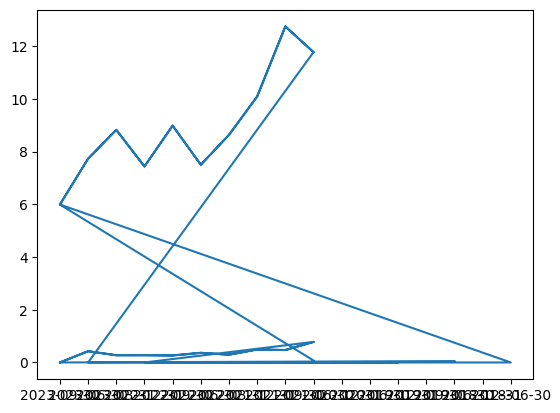

In [55]:
plt.plot(df["date"], df["cashPerShare"])

In [56]:
pe_ratio = df["priceEarningsRatio"]

<Axes: ylabel='Frequency'>

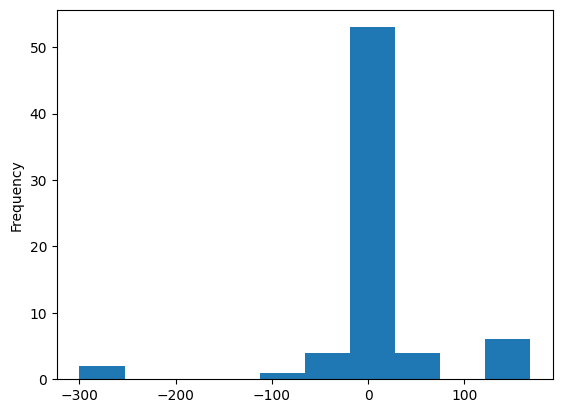

In [57]:
pe_ratio.plot(kind="hist")

In [58]:
top_5 = df.sort_values(by="priceEarningsRatio", ascending=False).head()

<Axes: xlabel='date'>

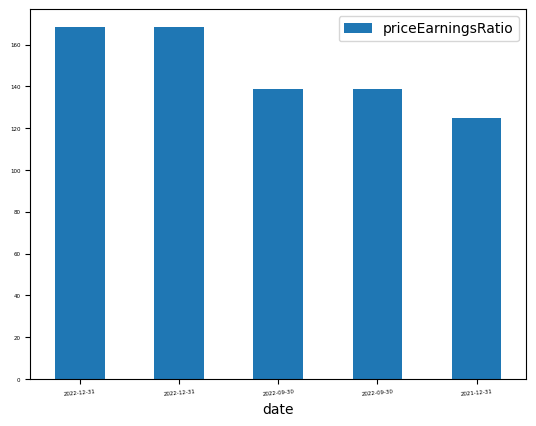

In [59]:
top_5.plot(x="date", y="priceEarningsRatio", kind="bar", rot=5, fontsize=4)

<Axes: xlabel='ebtPerEbit', ylabel='debtEquityRatio'>

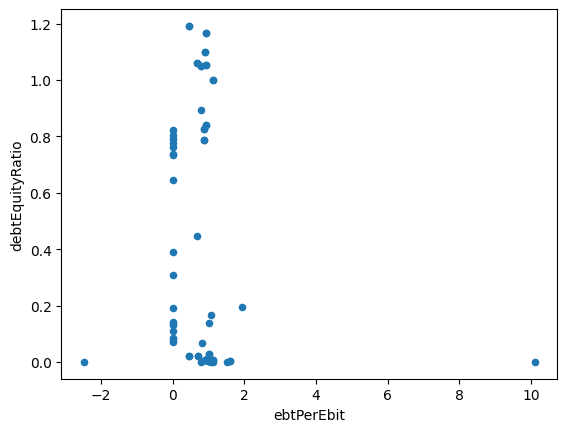

In [60]:
df.plot(x="ebtPerEbit", y="debtEquityRatio", kind="scatter")

In [61]:
cat_totals = df.groupby("symbol")["daysOfSalesOutstanding"].sum().sort_values()

<Axes: ylabel='symbol'>

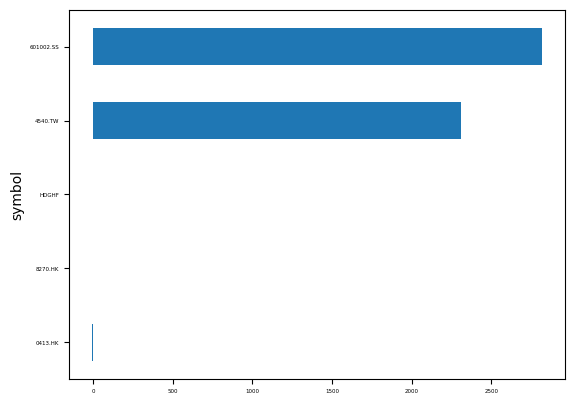

In [62]:
cat_totals.plot(kind="barh", fontsize=4)

In [63]:
df.tail()

,symbol,date,calendarYear,period,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,daysOfInventoryOutstanding,operatingCycle,daysOfPayablesOutstanding,cashConversionCycle,grossProfitMargin,operatingProfitMargin,pretaxProfitMargin,netProfitMargin,effectiveTaxRate,returnOnAssets,returnOnEquity,returnOnCapitalEmployed,netIncomePerEBT,ebtPerEbit,ebitPerRevenue,debtRatio,debtEquityRatio,longTermDebtToCapitalization,totalDebtToCapitalization,interestCoverage,cashFlowToDebtRatio,companyEquityMultiplier,receivablesTurnover,payablesTurnover,inventoryTurnover,fixedAssetTurnover,assetTurnover,operatingCashFlowPerShare,freeCashFlowPerShare,cashPerShare,payoutRatio,operatingCashFlowSalesRatio,freeCashFlowOperatingCashFlowRatio,cashFlowCoverageRatios,shortTermCoverageRatios,capitalExpenditureCoverageRatio,dividendPaidAndCapexCoverageRatio,dividendPayoutRatio,priceBookValueRatio,priceToBookRatio,priceToSalesRatio,priceEarningsRatio,priceToFreeCashFlowsRatio,priceToOperatingCashFlowsRatio,priceCashFlowRatio,priceEarningsToGrowthRatio,priceSalesRatio,dividendYield,enterpriseValueMultiple,priceFairValue
65,4540.TW,2022-06-30,2022,Q2,2.115101,0.969420,0.391820,95.143501,252.790909,347.934409,59.453388,288.481022,0.254645,0.125506,0.085555,0.054515,0.362806,0.006948,0.016419,0.020861,0.637194,0.681682,0.125506,0.449276,1.061723,0.445348,0.514969,9.948172,-0.001202,2.363188,0.945940,1.513791,0.356025,0.267743,0.127443,-0.04429,-0.697753,7.498116,0,-0.004236,15.754169,-0.001202,-0.00493,0.067777,0.067777,0,1.260195,1.260195,4.184296,19.188597,-62.701240,-987.805915,-987.805915,-0.424599,4.184296,0,36.049061,1.260195
66,4540.TW,2022-03-31,2022,Q1,2.190144,0.980275,0.457195,106.758937,360.176701,466.935637,90.434284,376.501353,0.315876,0.217999,0.174580,0.124807,0.285098,0.012516,0.029109,0.028297,0.714902,0.800830,0.217999,0.451410,1.049869,0.440267,0.512164,17.586335,-0.042174,2.325757,0.843021,0.995198,0.249877,0.212073,0.100283,-1.580284,-9.910903,8.630646,0,-0.189839,6.271595,-0.042174,-0.16816,0.189696,0.189696,0,1.263624,1.263624,5.417859,10.852440,-4.550544,-28.539171,-28.539171,0.121813,5.417859,0,29.222362,1.263624
67,4540.TW,2021-12-31,2021,Q4,2.307091,1.080290,0.509422,103.981205,287.192120,391.173325,99.836383,291.336942,0.221974,0.081336,0.070982,0.056233,0.207776,0.006487,0.013607,0.012241,0.792224,0.872692,0.081336,0.374588,0.785677,0.376231,0.439988,7.854971,-0.009796,2.097443,0.865541,0.901475,0.313379,0.296814,0.115365,-0.311217,-1.198119,10.087405,0,-0.031808,3.849782,-0.009796,-0.042169,0.350904,0.350904,0,1.235303,1.235303,5.105170,22.696386,-41.690352,-160.498787,-160.498787,-0.422011,5.105170,0,49.493938,1.235303
68,4540.TW,2021-09-30,2021,Q3,2.292218,1.265441,0.689989,93.702444,233.952034,327.654478,96.313063,231.341415,0.285376,0.168828,0.158628,0.116589,0.265016,0.016225,0.035368,0.0314,0.734984,0.939588,0.168828,0.385271,0.839844,0.385659,0.456476,20.089281,0.070023,2.179879,0.960487,0.934453,0.384694,0.366203,0.139162,1.978669,1.202817,12.741779,0,0.193859,0.607892,0.070023,0.277287,-2.550316,-2.550316,0,1.377578,1.377578,4.541108,9.737395,38.534551,23.424835,23.424835,0.172103,4.541108,0,25.141554,1.377578
69,4540.TW,2021-06-30,2021,Q2,2.362925,1.359192,0.674460,113.875580,225.026134,338.901714,99.111920,239.789794,0.258265,0.121035,0.104329,0.080495,0.228452,0.010534,0.022794,0.02089,0.771548,0.861968,0.121035,0.382490,0.827708,0.390488,0.452867,13.759494,0.02653,2.163996,0.790336,0.908064,0.399954,0.335802,0.13086,0.732156,-0.075312,11.767119,0,0.077546,-0.102863,0.02653,0.117398,-0.906731,-0.906731,0,1.577617,1.577617,5.571074,17.302632,-698.429067,71.842586,71.842586,0.026216,5.571074,0,39.470595,1.577617


In [67]:
df.groupby("symbol")["quickRatio"].count()

symbol
0413.HK      10
4540.TW      20
601002.SS    20
8270.HK      10
HDGHF        10
Name: quickRatio, dtype: int64

In [68]:
by_symbol = df.groupby("symbol")

In [83]:
for stock, frame in by_symbol:
    print(f"First 2 entries for {stock!r}")
    print("------------------------")
    print(frame.head(2), end="\n\n")

First 2 entries for '0413.HK'
------------------------
                      symbol  currentRatio  quickRatio  cashRatio  \
calendarYear period                                                 
2023         Q2      0413.HK      1.017325    0.133577   0.129775   
2022         Q4      0413.HK      1.152338    0.162596   0.158132   

                     daysOfSalesOutstanding  daysOfInventoryOutstanding  \
calendarYear period                                                       
2023         Q2                         0.0                         0.0   
2022         Q4                         0.0                         0.0   

                    operatingCycle  daysOfPayablesOutstanding  \
calendarYear period                                             
2023         Q2                NaN                        0.0   
2022         Q4                NaN                        0.0   

                    cashConversionCycle  grossProfitMargin  \
calendarYear period                         

symbol
0413.HK      Axes(0.125,0.11;0.775x0.77)
4540.TW      Axes(0.125,0.11;0.775x0.77)
601002.SS    Axes(0.125,0.11;0.775x0.77)
8270.HK      Axes(0.125,0.11;0.775x0.77)
HDGHF        Axes(0.125,0.11;0.775x0.77)
Name: currentRatio, dtype: object

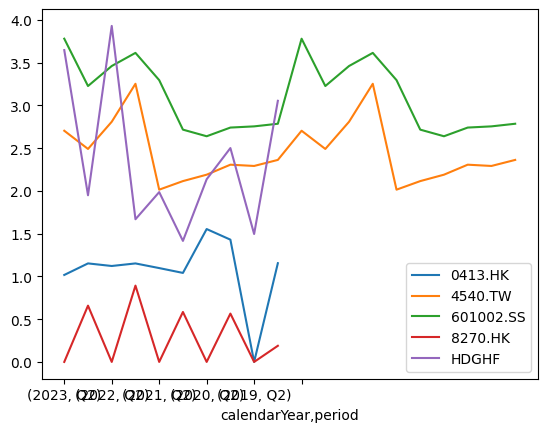

In [91]:
# df.set_index(['calendarYear','period'], inplace=True)
df.groupby('symbol')['currentRatio'].plot(legend=True)

In [90]:
df.reset_index()


,calendarYear,period,symbol,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,daysOfInventoryOutstanding,operatingCycle,daysOfPayablesOutstanding,cashConversionCycle,grossProfitMargin,operatingProfitMargin,pretaxProfitMargin,netProfitMargin,effectiveTaxRate,returnOnAssets,returnOnEquity,returnOnCapitalEmployed,netIncomePerEBT,ebtPerEbit,ebitPerRevenue,debtRatio,debtEquityRatio,longTermDebtToCapitalization,totalDebtToCapitalization,interestCoverage,cashFlowToDebtRatio,companyEquityMultiplier,receivablesTurnover,payablesTurnover,inventoryTurnover,fixedAssetTurnover,assetTurnover,operatingCashFlowPerShare,freeCashFlowPerShare,cashPerShare,payoutRatio,operatingCashFlowSalesRatio,freeCashFlowOperatingCashFlowRatio,cashFlowCoverageRatios,shortTermCoverageRatios,capitalExpenditureCoverageRatio,dividendPaidAndCapexCoverageRatio,dividendPayoutRatio,priceBookValueRatio,priceToBookRatio,priceToSalesRatio,priceEarningsRatio,priceToFreeCashFlowsRatio,priceToOperatingCashFlowsRatio,priceCashFlowRatio,priceEarningsToGrowthRatio,priceSalesRatio,dividendYield,enterpriseValueMultiple,priceFairValue
0,2023,Q3,601002.SS,3.780702,1.772534,0.261320,133.264308,222.322334,355.586642,91.092896,264.493746,0.120438,-0.025857,-0.029217,-0.022248,0.260029,-0.003012,-0.003703,-0.004103,0.761454,1.129960,-0.025857,0.006162,0.007576,0.000000,0.007519,-9.840727,-1.363799,1.229417,0.675350,0.988002,0.404818,0.489236,0.135392,0.0,0.0,0.000000,-3.435805,-0.062073,1.214717,-1.363799,-1.363799,4.657288,-0.983564,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,-9.312307,0.000000
1,2023,Q2,601002.SS,3.227067,1.292858,0.117159,146.209782,365.755397,511.965179,151.754945,360.210233,0.103366,-0.020300,-0.018237,-0.007911,0.594813,-0.000741,-0.000944,-0.00231,0.433781,0.898364,-0.020300,0.005915,0.007538,0.000000,0.007482,-5.401210,4.694296,1.274381,0.615554,0.593061,0.246066,0.348733,0.093664,0.154895,0.188512,0.427014,-0.091262,0.296461,1.217034,4.694296,4.694296,4.607575,4.556449,-0.091262,1.133145,1.133145,9.493201,-300.003551,26.311264,32.021700,32.021700,2.489656,9.493201,0.000076,-688.842518,1.133145
2,2023,Q1,601002.SS,3.461393,1.417210,0.127385,183.971976,417.462039,601.434016,170.990885,430.443131,0.203259,0.046186,0.045976,0.039291,0.130764,0.003557,0.004464,0.005007,0.854595,0.995443,0.046186,0.011456,0.014379,0.000000,0.014175,8.740869,0.310475,1.255104,0.489205,0.526344,0.215588,0.33414,0.090529,0.02,-0.024242,0.274065,0.056029,0.039291,-1.212120,0.310475,0.310475,-0.452055,-0.463802,0.056029,1.040182,1.040182,9.154689,58.250000,-192.225230,233.000000,233.000000,0.306813,9.154689,0.00024,110.555713,1.040182
3,2022,Q4,601002.SS,3.614871,1.477061,0.141330,127.494380,264.515396,392.009776,91.982792,300.026984,0.110885,-0.059100,-0.059283,0.009993,1.171748,0.001252,0.001547,-0.008753,-0.168558,1.003094,-0.059100,0.023483,0.029009,0.000000,0.028191,-15.399068,0.053311,1.235347,0.705913,0.978444,0.340245,0.445183,0.12528,0.006885,-0.101232,0.275675,0.143008,0.009993,-14.702851,0.053311,0.053311,-0.063683,-0.064268,0.143008,1.042200,1.042200,6.734091,168.476935,-45.835174,673.907742,673.907742,-12.252868,6.734091,0.000212,-698.718645,1.042200
4,2022,Q3,601002.SS,3.296193,1.263237,0.159217,131.483644,307.847390,439.331034,121.403205,317.927829,0.131493,0.030077,0.013469,0.011670,0.131881,0.001413,0.001795,0.004426,0.866473,0.447810,0.030077,0.016640,0.021140,0.000000,0.020702,7.752964,0.084912,1.270434,0.684496,0.741331,0.292353,0.476912,0.121069,0.007984,-0.004165,0.265921,0.129996,0.01167,-0.521715,0.084912,0.084912,-0.657153,-0.718536,0.129996,0.996006,0.996006,6.475526,138.718366,-1063.556033,554.873464,554.873464,-1.663929,6.475526,0.000234,190.482578,0.996006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2022,Q2,4540.TW,2.115

In [92]:
df1 = Globals.DATAFRAME_LIST[1]
df1.head()

,date,symbol,reportedCurrency,cik,fillingDate,acceptedDate,calendarYear,period,revenue,costOfRevenue,grossProfit,grossProfitRatio,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,interestIncome,interestExpense,depreciationAndAmortization,ebitda,ebitdaratio,operatingIncome,operatingIncomeRatio,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeBeforeTaxRatio,incomeTaxExpense,netIncome,netIncomeRatio,eps,epsdiluted,weightedAverageShsOut,weightedAverageShsOutDil,link,finalLink
0,2023-09-30,601002.SS,CNY,0000000000,2023-09-30,2023-09-29 20:00:00,2023,Q3,6.934089e+08,6.098959e+08,83512951.19,0.120438,36012244.06,49558283.08,15061988.37,64620271.45,-2330099.14,64146136.80,6.740420e+08,-1663331.14,1821957.98,35633841.08,17704449.23,0.025532,-17929391.85,-0.025857,-2330099.14,-20259490.99,-0.029217,-5268058.84,-15426674.20,-0.022248,0.0000,0.0000,0,0,,
1,2023-06-30,601002.SS,CNY,0000000000,2023-06-30,2023-06-29 20:00:00,2023,Q2,4.994758e+08,4.478468e+08,51628979.65,0.103366,27859549.15,-4850083.38,10652193.95,5802110.57,1030539.39,64758690.01,5.126055e+08,835193.97,1877270.84,3370724.05,-6768809.07,-0.013552,-10139533.12,-0.020300,1030539.39,-9108993.73,-0.018237,-5418145.53,-3951306.26,-0.007911,-0.0041,-0.0041,955972506,955972506,,
2,2023-03-31,601002.SS,CNY,0000000000,2023-03-31,2023-03-30 20:00:00,2023,Q1,4.866175e+08,3.877082e+08,98909279.53,0.203259,17140457.91,23599332.41,16424326.14,40023658.55,1090222.74,58254339.20,4.459625e+08,-291887.02,2571249.31,17355227.07,39830181.58,0.081851,22474954.51,0.046186,-102423.49,22372531.02,0.045976,2925522.43,19119450.12,0.039291,0.0200,0.0200,955972506,955972506,,
3,2022-12-31,601002.SS,CNY,0000000000,2022-12-31,2022-12-30 19:00:00,2022,Q4,6.595417e+08,5.864082e+08,73133528.76,0.110885,34554170.09,-40187231.17,22048736.89,-18138494.28,64142787.87,80558463.68,6.669666e+08,1668415.19,2531246.36,32609473.06,-6369362.77,-0.009657,-38978835.83,-0.059100,-120604.02,-39099439.85,-0.059283,-45814691.94,6590536.38,0.009993,0.0069,0.0069,957201183,957201183,,
4,2022-09-30,601002.SS,CNY,0000000000,2022-09-30,2022-09-29 20:00:00,2022,Q3,6.548301e+08,5.687246e+08,86105560.09,0.131493,25927321.46,57418592.70,16677237.76,74095830.46,-32629267.82,67393884.10,6.361185e+08,-903752.09,2540347.78,2237027.48,21932252.16,0.033493,19695224.68,0.030077,-10875508.95,8819715.73,0.013469,1163150.95,7642048.15,0.011670,0.0080,0.0080,957194070,957194070,,
